# EDA — Customer Support Ticket Dataset

**Projeto de Bloco — TP1**
Grupo: Anderson, Breno e Francisco

Este notebook cobre integralmente as Tarefas 1, 2 e 3 do TP:

| Seção | Conteúdo | Tarefa |
| --- | --- | --- |
| 0 | Documentação técnica do dataset (fonte, características, motivo da escolha) | 1 |
| 1 | Compreensão do problema e do dataset | 2a |
| 2 | Inspeção inicial | 2b |
| 3 | Verificação da qualidade dos dados | 2c |
| 4 | Limpeza e preparação dos dados | 2d |
| 5 | Análise univariada (histogramas e gráficos de distribuição) | 2e |
| 6 | Hipóteses sobre as intenções dos usuários | 3 |
| 7 | Conclusões e ligação com a API FastAPI | — |

> **Regra metodológica adotada:** nenhuma decisão de limpeza é tomada antes da seção 3.
> Ausência de dado não é tratada como erro até que sua origem seja compreendida.

## 0. Documentação técnica do dataset (Tarefa 1)

### 0.1 Fonte (origem do dataset)

| Item | Valor |
| --- | --- |
| Nome | Customer Support Ticket Dataset |
| Publicador no Kaggle | `suraj520` |
| URL | https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset/data |
| Arquivo | `customer_support_tickets.csv` |
| Licença declarada | CC0: Public Domain |
| Cópia usada aqui | `data/customer_support_tickets.csv`, preservada sem alterações |

A publicação descreve um conjunto de tickets de suporte ao cliente sobre produtos de
tecnologia, contendo o texto livre do cliente, a categorização do atendimento e métricas
operacionais. **A publicação não informa a empresa de origem nem o processo de coleta.**
Como será demonstrado nas seções 3 e 5, as evidências estatísticas indicam que se trata de
um conjunto **gerado sinteticamente**, e não de um extrato de um sistema real de
atendimento. Registramos isso já na documentação porque condiciona todas as decisões de
modelagem posteriores.

### 0.2 Principais características

- **8.469 registros × 17 colunas**, uma linha por ticket de suporte.
- Granularidade: um ticket — não um cliente, não uma conversa completa.

| Grupo | Colunas |
| --- | --- |
| Identificação | `Ticket ID` |
| Cliente (dados pessoais) | `Customer Name`, `Customer Email`, `Customer Age`, `Customer Gender` |
| Produto | `Product Purchased`, `Date of Purchase` |
| Intenção / conteúdo | `Ticket Type`, `Ticket Subject`, `Ticket Description` |
| Operação do atendimento | `Ticket Status`, `Resolution`, `Ticket Priority`, `Ticket Channel` |
| Tempos e avaliação | `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating` |

Colunas candidatas a **rótulo de intenção**: `Ticket Type` (5 classes) e `Ticket Subject`
(16 classes). Coluna de **entrada textual**: `Ticket Description`.

### 0.3 Motivo da escolha do dataset

1. **Alinhamento direto ao domínio do projeto.** O sistema a ser construído no bloco é um
   atendimento ao cliente com IA; o dataset é exatamente uma base de tickets de suporte,
   com texto livre do cliente e categorias de atendimento já rotuladas.
2. **Rótulo de intenção disponível sem anotação manual.** `Ticket Type` e `Ticket Subject`
   fornecem um alvo pronto para a futura classificação servida pela rota `POST /predict`.
3. **Riqueza para a EDA estatística.** Combina variáveis numéricas (`Customer Age`,
   `Customer Satisfaction Rating`), categóricas (tipo, status, prioridade, canal),
   temporais (datas e timestamps) e textuais — permitindo exercitar todos os passos
   exigidos no enunciado.
4. **Relevância para a etapa de segurança do bloco.** O conjunto contém nome e e-mail
   (dados pessoais) e entrada textual não confiável, que são exatamente os ativos
   protegidos no DFD e na análise CIA da API (ver `others/dfd-and-cia.md`).
5. **Licença permissiva (CC0)**, o que autoriza versionar o `.csv` no repositório, como
   exige a estrutura de entrega.

> **Ressalva.** A escolha foi determinada pelo enunciado do TP. A EDA abaixo mostra que o
> dataset tem limitações severas para treinar um classificador de intenção (rótulos
> estatisticamente independentes do texto). Isso não invalida a escolha, mas define com
> precisão o que é e o que não é possível prometer nas próximas entregas.

## 1. Compreensão do problema e do dataset (2a)

**Problema de negócio.** Um time de atendimento recebe tickets em texto livre por vários
canais. Antes de responder, é preciso saber *o que o cliente quer* — a sua **intenção** —
para rotear o ticket, priorizá-lo e, futuramente, gerar uma resposta automática.

**Problema técnico deste TP.** Ainda não treinamos modelo. O objetivo é responder:

1. O que exatamente cada linha representa e quais variáveis carregam sinal de intenção?
2. Os dados têm qualidade suficiente para sustentar um classificador de intenção?
3. Que padrões de distribuição permitem formular hipóteses testáveis sobre as intenções?

| Elemento | Definição |
| --- | --- |
| Unidade de análise | Um ticket de suporte |
| Variável resposta candidata (futura) | `Ticket Type` (5 classes) ou `Ticket Subject` (16 classes) |
| Variável preditora principal (futura) | `Ticket Description` (texto livre) |
| Variáveis de contexto | Canal, prioridade, status, produto, perfil do cliente |
| Dados pessoais presentes | `Customer Name`, `Customer Email` (e, indiretamente, idade/gênero) |

**Perguntas que guiam esta EDA:**

- **Q1.** As classes de intenção estão balanceadas ou desbalanceadas?
- **Q2.** Os valores ausentes são aleatórios ou dependem do estado do ticket?
- **Q3.** O texto do ticket é consistente com o rótulo de intenção atribuído?
- **Q4.** Quais variáveis exigem tratamento por conterem dados pessoais?

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# O notebook funciona tanto executado a partir de `eda/` quanto da raiz do repositório.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_PATH = PROJECT_ROOT / "data" / "customer_support_tickets.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Raiz do projeto :", PROJECT_ROOT)
print("Dataset         :", DATASET_PATH.name, "| encontrado:", DATASET_PATH.exists())

Raiz do projeto : D:\_infnet\26E3_26E4\Projeto_de_bloco\_codigo\anderson_breno_francisco
Dataset         : customer_support_tickets.csv | encontrado: True


### Teste qui-quadrado de independência (implementação própria)

O ambiente desta máquina bloqueia o carregamento das bibliotecas nativas do SciPy
(política de *Application Control* do Windows). Para que o notebook seja reprodutível
sem essa dependência, o teste qui-quadrado de independência e o V de Cramér são
implementados abaixo com `numpy` e `math`.

O p-valor usa a função gama incompleta regularizada superior `Q(a, x)` — série de
potências para `x < a+1` e fração continuada de Lentz caso contrário. A célula inclui uma
verificação contra dois valores críticos tabelados (`χ²=3,841`, gl=1 e `χ²=11,070`, gl=5,
ambos com p = 0,05).

In [2]:
def _gama_q(a: float, x: float) -> float:
    """Função gama incompleta regularizada superior Q(a, x) = 1 - P(a, x)."""
    if x < a + 1.0:  # série de potências
        termo = 1.0 / a
        soma = termo
        for n in range(1, 1000):
            termo *= x / (a + n)
            soma += termo
            if abs(termo) < abs(soma) * 1e-14:
                break
        return 1.0 - soma * math.exp(-x + a * math.log(x) - math.lgamma(a))

    minimo = 1e-300  # fração continuada (algoritmo modificado de Lentz)
    b = x + 1.0 - a
    c = 1.0 / minimo
    d = 1.0 / b
    h = d
    for i in range(1, 1000):
        an = -i * (i - a)
        b += 2.0
        d = an * d + b
        d = minimo if abs(d) < minimo else d
        c = b + an / c
        c = minimo if abs(c) < minimo else c
        d = 1.0 / d
        delta = d * c
        h *= delta
        if abs(delta - 1.0) < 1e-14:
            break
    return h * math.exp(-x + a * math.log(x) - math.lgamma(a))


def qui_quadrado(tabela: pd.DataFrame) -> dict:
    """Teste de independência para uma tabela de contingência. Devolve chi2, gl, p e V."""
    observado = tabela.to_numpy(dtype=float)
    n = observado.sum()
    esperado = np.outer(observado.sum(axis=1), observado.sum(axis=0)) / n
    chi2 = float(((observado - esperado) ** 2 / esperado).sum())
    graus_liberdade = (observado.shape[0] - 1) * (observado.shape[1] - 1)
    return {
        "chi2": chi2,
        "gl": graus_liberdade,
        "p": _gama_q(graus_liberdade / 2.0, chi2 / 2.0),
        "cramer_v": math.sqrt(chi2 / (n * (min(observado.shape) - 1))),
    }


# Validação contra valores críticos tabelados (ambos devem resultar em p = 0,0500):
print(f"Q(chi2=3.841, gl=1) = {_gama_q(0.5, 3.841 / 2):.4f}  (esperado 0,0500)")
print(f"Q(chi2=11.070, gl=5) = {_gama_q(2.5, 11.070 / 2):.4f}  (esperado 0,0500)")

Q(chi2=3.841, gl=1) = 0.0500  (esperado 0,0500)
Q(chi2=11.070, gl=5) = 0.0500  (esperado 0,0500)


## 2. Inspeção inicial (2b)

Objetivo: descobrir a forma do dado — dimensões, tipos, primeiras linhas e estatísticas
descritivas — **sem alterar nada**. O `DataFrame` original fica em `raw_df` e nunca é
modificado; todas as transformações ocorrem em uma cópia, na seção 4.

In [3]:
raw_df = pd.read_csv(DATASET_PATH)

print(f"Linhas : {raw_df.shape[0]:,}")
print(f"Colunas: {raw_df.shape[1]}")
print(f"Memória: {raw_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
raw_df.head()

Linhas : 8,469
Colunas: 17
Memória: 9.13 MB


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [5]:
# Estatísticas descritivas das variáveis numéricas.
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticket ID,8469.0,4235.000000,2444.934048,1.0,2118.0,4235.0,6352.0,8469.0
Customer Age,8469.0,44.026804,15.296112,18.0,31.0,44.0,57.0,70.0
Customer Satisfaction Rating,2769.0,2.991333,1.407016,1.0,2.0,3.0,4.0,5.0


In [6]:
# Estatísticas descritivas das variáveis categóricas e textuais.
raw_df.describe(include="object").T

C:\Users\Francisco\AppData\Local\Temp\ipykernel_35144\1178203134.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  raw_df.describe(include="object").T


,count,unique,top,freq
Customer Name,8469,8028,Michael Garcia,5
Customer Email,8469,8320,asmith@example.com,4
Customer Gender,8469,3,Male,2896
Product Purchased,8469,42,Canon EOS,240
Date of Purchase,8469,730,2020-10-21,24
Ticket Type,8469,5,Refund request,1752
Ticket Subject,8469,16,Refund request,576
Ticket Description,8469,8077,I'm having an issue with the {product_purchase...,25
Ticket Status,8469,3,Pending Customer Response,2881
Resolution,2769,2769,Case maybe show recently my computer follow.,1


In [7]:
# Amostra do conteúdo textual — a variável que futuramente alimentará o modelo.
# Nome e e-mail são omitidos deliberadamente: são dados pessoais (ver seção 3.5).
for _, row in raw_df.sample(3, random_state=42).iterrows():
    print(f"[{row['Ticket Type']} | {row['Ticket Subject']}]")
    print(row["Ticket Description"][:250].replace("\n", " "), "...")
    print("-" * 95)

[Refund request | Product setup]
I'm having an issue with the {product_purchased}. Please assist. I'm using xda-developer for something different. If there are issues with the {product_purchased} it's likely you are not using the I've tried clearing the cache and data for the {produ ...
-----------------------------------------------------------------------------------------------
[Product inquiry | Battery life]
I'm having trouble connecting my {product_purchased} to my home Wi-Fi network. It doesn't detect any networks, although other devices are connecting fine. What can be done to resolve this issue? I will refer to this issue I've checked for any availab ...
-----------------------------------------------------------------------------------------------
[Billing inquiry | Refund request]
 Please give credit to: @joeyclay I'm concerned about the security of my {product_purchased} and would like to ensure that my data is safe. ...
-----------------------------------------------------

### Interpretação da inspeção inicial

- O dataset tem **8.469 linhas e 17 colunas**; cada linha é um ticket, identificado por
  `Ticket ID`.
- Apenas duas colunas são numéricas de fato: `Customer Age` (int) e
  `Customer Satisfaction Rating` (float). `Ticket ID` também é numérico, mas é um
  **identificador** e não uma grandeza — não deve entrar em estatística descritiva nem em
  modelo.
- Três colunas que representam **datas/timestamps** (`Date of Purchase`,
  `First Response Time`, `Time to Resolution`) foram lidas como `object` (texto). É um tipo
  incorreto e será convertido na seção 4.
- `describe(include="object")` mostra baixa cardinalidade em `Ticket Type` (5),
  `Ticket Subject` (16), `Ticket Status` (3), `Ticket Priority` (4) e `Ticket Channel` (4):
  são categóricas bem definidas, sem variação de grafia aparente.
- A amostra de texto já revela uma anomalia: as descrições contêm a string literal
  `{product_purchased}`, ou seja, um **placeholder de template não substituído**.
  Investigado na seção 3.4.
- `Resolution`, `First Response Time`, `Time to Resolution` e
  `Customer Satisfaction Rating` apresentam contagem menor que 8.469 — há ausências
  concentradas justamente nas variáveis de encerramento do atendimento (seção 3.2).

## 3. Verificação da qualidade dos dados (2c)

Cinco frentes de verificação:

1. Completude (valores ausentes) e duplicidade
2. Mecanismo da ausência — aleatório ou estrutural?
3. Validade de domínio das variáveis categóricas e numéricas
4. Consistência do texto e coerência entre texto e rótulo
5. Presença de dados pessoais (relevante para a análise CIA da API)

### 3.1 Completude, cardinalidade e duplicidade

In [8]:
quality_report = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "nao_nulos": raw_df.notna().sum(),
        "ausentes": raw_df.isna().sum(),
        "ausentes_pct": raw_df.isna().mean().mul(100).round(2),
        "valores_unicos": raw_df.nunique(dropna=False),
        "cardinalidade_pct": (raw_df.nunique(dropna=False) / len(raw_df) * 100).round(2),
    }
)
quality_report.sort_values("ausentes_pct", ascending=False)

,dtype,nao_nulos,ausentes,ausentes_pct,valores_unicos,cardinalidade_pct
Customer Satisfaction Rating,float64,2769,5700,67.30,6,0.07
Resolution,str,2769,5700,67.30,2770,32.71
Time to Resolution,str,2769,5700,67.30,2729,32.22
First Response Time,str,5650,2819,33.29,5471,64.60
Ticket ID,int64,8469,0,0.00,8469,100.00
Customer Name,str,8469,0,0.00,8028,94.79
Customer Email,str,8469,0,0.00,8320,98.24
Customer Age,int64,8469,0,0.00,53,0.63
Customer Gender,str,8469,0,0.00,3,0.04
Ticket Subject,str,8469,0,0.00,16,0.19


In [9]:
print("Linhas totalmente duplicadas :", raw_df.duplicated().sum())
print("Ticket ID duplicados         :", raw_df["Ticket ID"].duplicated().sum())
print("Ticket ID é sequencial 1..N  :", raw_df["Ticket ID"].equals(pd.Series(range(1, len(raw_df) + 1))))
print("Descrições de ticket repetidas:", raw_df["Ticket Description"].duplicated().sum())

Linhas totalmente duplicadas : 0
Ticket ID duplicados         : 0
Ticket ID é sequencial 1..N  : True
Descrições de ticket repetidas: 392


### 3.2 O mecanismo da ausência é estrutural, não aleatório

Quatro colunas têm ausências. A pergunta correta não é "quantos faltam", mas **por que
faltam**. Cruzamos cada uma com `Ticket Status`.

In [10]:
for column in ["Resolution", "Time to Resolution", "Customer Satisfaction Rating", "First Response Time"]:
    tabela = pd.crosstab(raw_df["Ticket Status"], raw_df[column].isna())
    tabela.columns = ["preenchido", "ausente"]
    print(f"### {column}")
    print(tabela.to_string(), "\n")

### Resolution
                           preenchido  ausente
Ticket Status                                 
Closed                           2769        0
Open                                0     2819
Pending Customer Response           0     2881 

### Time to Resolution
                           preenchido  ausente
Ticket Status                                 
Closed                           2769        0
Open                                0     2819
Pending Customer Response           0     2881 

### Customer Satisfaction Rating
                           preenchido  ausente
Ticket Status                                 
Closed                           2769        0
Open                                0     2819
Pending Customer Response           0     2881 

### First Response Time
                           preenchido  ausente
Ticket Status                                 
Closed                           2769        0
Open                                0     2819
Pendin

### 3.3 Validade de domínio das variáveis categóricas e numéricas

In [11]:
categoricas = [
    "Ticket Type",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel",
    "Customer Gender",
]
for column in categoricas:
    contagem = raw_df[column].value_counts(dropna=False)
    print(f"### {column}  (n={raw_df[column].nunique()} categorias)")
    print(contagem.to_string())
    print(f"  -> min/max: {contagem.min()} / {contagem.max()} | "
          f"razão de desbalanceamento: {contagem.max() / contagem.min():.2f}\n")

### Ticket Type  (n=5 categorias)
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
  -> min/max: 1634 / 1752 | razão de desbalanceamento: 1.07

### Ticket Status  (n=3 categorias)
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
  -> min/max: 2769 / 2881 | razão de desbalanceamento: 1.04

### Ticket Priority  (n=4 categorias)
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
  -> min/max: 2063 / 2192 | razão de desbalanceamento: 1.06

### Ticket Channel  (n=4 categorias)
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
  -> min/max: 2073 / 2143 | razão de desbalanceamento: 1.03

### Customer Gender  (n=3 categorias)
Customer Gender
Male      2896
Female    2887
Other     2686
  -> min/max: 2686 / 2896 | razão de desbalanceamento: 1

In [12]:
# Verificações de intervalo e formato.
print("Idade: min =", raw_df["Customer Age"].min(), "| max =", raw_df["Customer Age"].max())
print("Satisfação: valores distintos =", sorted(raw_df["Customer Satisfaction Rating"].dropna().unique()))
print("Espaços em branco nas bordas de colunas de texto:",
      int(sum(raw_df[c].astype(str).str.strip().ne(raw_df[c].astype(str)).sum()
              for c in raw_df.select_dtypes("object").columns)))

# Conversão de datas apenas para teste — nada é alterado ainda.
for column in ["Date of Purchase", "First Response Time", "Time to Resolution"]:
    convertida = pd.to_datetime(raw_df[column], errors="coerce")
    falhas = convertida.isna().sum() - raw_df[column].isna().sum()
    print(f"{column:22s} -> falhas de conversão: {falhas} | "
          f"intervalo: {convertida.min()} .. {convertida.max()}")

Idade: min = 18 | max = 70
Satisfação: valores distintos = [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


Espaços em branco nas bordas de colunas de texto: 14219
Date of Purchase       -> falhas de conversão: 0 | intervalo: 2020-01-01 00:00:00 .. 2021-12-30 00:00:00
First Response Time    -> falhas de conversão: 0 | intervalo: 2023-05-31 21:55:39 .. 2023-06-02 00:54:21
Time to Resolution     -> falhas de conversão: 0 | intervalo: 2023-05-31 21:53:30 .. 2023-06-02 00:55:33


C:\Users\Francisco\AppData\Local\Temp\ipykernel_35144\740338845.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in raw_df.select_dtypes("object").columns)))


In [13]:
# Coerência temporal: a resolução deveria ocorrer DEPOIS da primeira resposta.
primeira_resposta = pd.to_datetime(raw_df["First Response Time"], errors="coerce")
resolucao = pd.to_datetime(raw_df["Time to Resolution"], errors="coerce")
delta_horas = (resolucao - primeira_resposta).dt.total_seconds() / 3600

validos = int(delta_horas.notna().sum())
invertidos = int((delta_horas < 0).sum())
print("Tickets com ambos os timestamps:", validos)
print("Resolução ANTES da 1a resposta :", invertidos,
      f"({invertidos / validos * 100:.1f}% dos casos válidos)")
print("\nDiferença (resolução - 1a resposta), em horas:")
print(delta_horas.describe().round(2).to_string())

Tickets com ambos os timestamps: 2769
Resolução ANTES da 1a resposta : 1365 (49.3% dos casos válidos)

Diferença (resolução - 1a resposta), em horas:
count    2769.00
mean       -0.06
std         9.56
min       -23.23
25%        -6.93
50%         0.17
75%         6.48
max        23.47


### 3.4 Consistência do texto e coerência entre texto e rótulo

In [14]:
descricao = raw_df["Ticket Description"]
placeholder = descricao.str.contains(r"\{product_purchased\}", regex=True)
print(f"Descrições com o placeholder literal '{{product_purchased}}': "
      f"{placeholder.sum():,} de {len(descricao):,} ({placeholder.mean() * 100:.1f}%)")

primeira_frase = descricao.str.split(".").str[0].str.strip()
print("\nModelos (templates) distintos de primeira frase:", primeira_frase.nunique())
print("\nTop 5 templates:")
print(primeira_frase.value_counts().head(5).to_string())

Descrições com o placeholder literal '{product_purchased}': 8,469 de 8,469 (100.0%)

Modelos (templates) distintos de primeira frase: 16

Top 5 templates:
Ticket Description
I'm having an issue with the {product_purchased}                                                               5868
I'm unable to access my {product_purchased} account                                                             189
I've forgotten my password for my {product_purchased} account, and the password reset option is not working     186
The {product_purchased} is unable to establish a stable internet connection                                     184
I'm encountering a software bug in the {product_purchased}                                                      183


In [15]:
# Q3: o texto é consistente com o rótulo? Se houvesse sinal, cada template se concentraria
# em poucos assuntos. Testamos com o qui-quadrado de independência.
pares = {
    "Template da 1a frase  x  Ticket Subject": (primeira_frase, raw_df["Ticket Subject"]),
    "Template da 1a frase  x  Ticket Type   ": (primeira_frase, raw_df["Ticket Type"]),
    "Ticket Subject        x  Ticket Type   ": (raw_df["Ticket Subject"], raw_df["Ticket Type"]),
    "Ticket Channel        x  Ticket Type   ": (raw_df["Ticket Channel"], raw_df["Ticket Type"]),
    "Ticket Priority       x  Ticket Type   ": (raw_df["Ticket Priority"], raw_df["Ticket Type"]),
}

resultados = []
for nome, (a, b) in pares.items():
    resultado = qui_quadrado(pd.crosstab(a, b))
    resultados.append({"par": nome.strip(), **resultado})
    print(f"{nome} -> chi2={resultado['chi2']:8.1f}  gl={resultado['gl']:4d}  "
          f"p={resultado['p']:.4f}  V de Cramér={resultado['cramer_v']:.4f}")

print("\n(p > 0,05: NÃO se rejeita a independência — não há associação detectável.")
print(" V de Cramér próximo de 0: a associação, se existisse, seria desprezível.)")

Template da 1a frase  x  Ticket Subject -> chi2=   197.1  gl= 225  p=0.9106  V de Cramér=0.0394


Template da 1a frase  x  Ticket Type    -> chi2=    40.5  gl=  60  p=0.9746  V de Cramér=0.0346
Ticket Subject        x  Ticket Type    -> chi2=    39.6  gl=  60  p=0.9807  V de Cramér=0.0342
Ticket Channel        x  Ticket Type    -> chi2=    11.9  gl=  12  p=0.4578  V de Cramér=0.0216
Ticket Priority       x  Ticket Type    -> chi2=    10.6  gl=  12  p=0.5613  V de Cramér=0.0205

(p > 0,05: NÃO se rejeita a independência — não há associação detectável.
 V de Cramér próximo de 0: a associação, se existisse, seria desprezível.)


In [16]:
# Distribuição do texto entre os rótulos: se houvesse sinal, a tabela seria esparsa
# (cada template concentrado em poucos assuntos). Ela é densa e homogênea.
top_templates = primeira_frase.value_counts().index[1:6]
pd.crosstab(
    primeira_frase[primeira_frase.isin(top_templates)].str[:42],
    raw_df.loc[primeira_frase.isin(top_templates), "Ticket Type"],
)

Ticket Type,Billing inquiry,Cancellation request,Product inquiry,Refund request,Technical issue
Ticket Description,,,,,
I'm encountering a software bug in the {pr,37,33,38,34,41
I'm unable to access my {product_purchased,34,37,40,41,37
I've forgotten my password for my {product,42,36,30,38,40
My {product_purchased} is making strange n,29,44,35,34,40
The {product_purchased} is unable to estab,46,41,40,28,29


In [17]:
# Exemplo concreto da incoerência: o mesmo texto sob rótulos completamente diferentes.
exemplo = descricao.value_counts().index[0]
amostra_incoerencia = raw_df.loc[descricao == exemplo, ["Ticket Type", "Ticket Subject"]]
print("Texto idêntico aparece", len(amostra_incoerencia), "vezes, rotulado como:")
print(amostra_incoerencia.to_string(index=False))

Texto idêntico aparece 25 vezes, rotulado como:
         Ticket Type           Ticket Subject
     Product inquiry             Battery life
Cancellation request                Data loss
      Refund request   Product recommendation
     Billing inquiry Peripheral compatibility
     Technical issue          Network problem
     Billing inquiry         Delivery problem
Cancellation request           Refund request
Cancellation request           Hardware issue
     Technical issue           Hardware issue
      Refund request         Delivery problem
Cancellation request    Product compatibility
Cancellation request           Refund request
      Refund request           Account access
     Technical issue                Data loss
     Technical issue             Battery life
     Technical issue           Refund request
     Billing inquiry     Cancellation request
     Technical issue     Installation support
     Billing inquiry Peripheral compatibility
     Technical issue            

### 3.5 Dados pessoais (insumo para a análise CIA da API)

In [18]:
colunas_pessoais = ["Customer Name", "Customer Email", "Customer Age", "Customer Gender"]
print("Colunas com dados pessoais:", colunas_pessoais)
print("\nDomínios de e-mail mais frequentes:")
print(raw_df["Customer Email"].str.split("@").str[1].value_counts().head().to_string())
print("\nNomes distintos:", raw_df["Customer Name"].nunique(),
      "| E-mails distintos:", raw_df["Customer Email"].nunique())

Colunas com dados pessoais: ['Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender']

Domínios de e-mail mais frequentes:


Customer Email
example.com    2904
example.org    2796
example.net    2769

Nomes distintos: 8028 | E-mails distintos: 8320


### Interpretação da qualidade dos dados

**Completude e duplicidade (3.1).** Não há linha totalmente duplicada nem `Ticket ID`
repetido — o identificador é sequencial de 1 a 8.469 e serve como chave. Quatro colunas
têm ausência: `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` com
**67,3% (5.700 linhas)** e `First Response Time` com **33,3% (2.819 linhas)**. Há **392
descrições de ticket repetidas** — mesmo texto em tickets diferentes.

**A ausência é 100% estrutural, não aleatória (3.2).** As tabelas cruzadas são
determinísticas, sem uma única exceção:

- `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` estão preenchidas
  **exatamente nos 2.769 tickets com status `Closed`** e ausentes em todos os demais.
- `First Response Time` está ausente **exatamente nos 2.819 tickets `Open`** e preenchida
  nos `Closed` e `Pending Customer Response`.

Isso responde à **Q2**: a ausência é MNAR (*missing not at random*) e é **informativa** —
ela codifica o estágio do ticket no fluxo de atendimento. **Consequência prática:
imputar esses valores seria um erro grave**, pois inventaria uma nota de satisfação para
um ticket que nem foi encerrado. A decisão correta (aplicada na seção 4) é preservar o
`NaN` e analisar essas variáveis apenas no subconjunto em que fazem sentido.

**Validade de domínio (3.3).** Nenhuma categoria inválida, nenhum erro de grafia, nenhum
espaço em branco nas bordas, nenhuma falha de conversão de data. Idade entre **18 e 70**
anos e satisfação em `{1,2,3,4,5}` — ambos dentro do esperado, sem outliers.
O ponto notável é a **razão de desbalanceamento próxima de 1,00** em todas as categóricas:
`Ticket Type` varia de 1.634 a 1.752 registros, canal de 2.073 a 2.143, prioridade de
2.063 a 2.192. Isso responde à **Q1**: as classes estão **artificialmente balanceadas**.
Uma base real de suporte é sempre desbalanceada.

**Incoerência temporal (3.3).** Em **49% dos tickets encerrados a "resolução" ocorre antes
da primeira resposta** — o que é logicamente impossível. Além disso, todos os timestamps
de atendimento estão comprimidos em uma janela de ~27 horas (31/05/2023 a 02/06/2023),
enquanto as compras vão de 2020 a 2021. Esses campos **não representam tempos de
atendimento reais** e não podem ser usados como métrica operacional.

**Texto e rótulo (3.4).** Três achados encadeados:

1. **100% das 8.469 descrições contêm o placeholder literal `{product_purchased}`** — o
   template de geração nunca foi renderizado. É um defeito de dado que precisa ser tratado
   antes de qualquer vetorização de texto.
2. Existem apenas **16 templates distintos de primeira frase**, e um único deles
   (`I'm having an issue with the {product_purchased}`) cobre **5.868 tickets (69%)**.
3. O teste qui-quadrado **não rejeita a independência em nenhum dos cinco pares testados**:
   template × `Ticket Subject` (p=0,911), template × `Ticket Type` (p=0,975),
   `Ticket Subject` × `Ticket Type` (p=0,981), canal × tipo (p=0,458) e prioridade × tipo.
   Todos os V de Cramér ficam abaixo de 0,04 — associação desprezível mesmo que existisse.
   Em outras palavras: o texto **não prediz** o rótulo, e os dois rótulos **não concordam
   entre si**. A tabela cruzada e a célula seguinte mostram o caso extremo — o mesmo texto
   idêntico aparece rotulado sob tipos e assuntos completamente diferentes.

Isso responde à **Q3**, e é o achado mais importante desta EDA: **os rótulos foram
atribuídos de forma aparentemente aleatória em relação ao conteúdo**.

**Dados pessoais (3.5).** `Customer Name` e `Customer Email` são dados pessoais e devem
ser tratados como confidenciais mesmo sendo sintéticos (domínios `example.com/.org/.net`,
reservados pela RFC 2606). Isso responde à **Q4** e alimenta diretamente a coluna
"Confidencialidade" da tríade CIA em `others/dfd-and-cia.md`: essas colunas não podem
aparecer em logs, gráficos, respostas da API ou exemplos de documentação.

## 4. Limpeza e preparação dos dados (2d)

Cada transformação abaixo é consequência direta de um achado da seção 3. Nada é removido
ou imputado "por padrão".

| # | Transformação | Justificativa (achado da seção 3) |
| --- | --- | --- |
| 1 | Padronizar nomes de colunas para `snake_case` | Ergonomia; nomes com espaço exigem aspas e quebram `df.coluna` |
| 2 | Converter as 3 colunas de data para `datetime` | 3.3 — foram lidas como texto |
| 3 | Converter as 5 categóricas para `category` | 3.3 — domínios fechados e válidos; reduz memória |
| 4 | **Não** imputar ausentes | 3.2 — ausência é estrutural/MNAR; imputar inventaria dados |
| 5 | **Não** remover linhas | 3.1 — não há duplicata de chave nem linha inválida |
| 6 | Remover o placeholder `{product_purchased}` do texto | 3.4 — ruído de template presente em 100% das linhas |
| 7 | Derivar `descricao_limpa`, `descricao_n_caracteres`, `descricao_n_palavras` | Variáveis numéricas para a análise univariada do texto |
| 8 | Derivar `template_primeira_frase` | 3.4 — captura o único sinal textual identificável |
| 9 | Derivar `ticket_encerrado` (booleano) | 3.2 — torna explícito o mecanismo da ausência |
| 10 | Isolar `dados_pessoais` em um objeto separado | 3.5 — reduz o risco de vazamento na análise |

In [19]:
df = raw_df.copy()

# (1) snake_case
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# (2) tipos temporais
colunas_data = ["date_of_purchase", "first_response_time", "time_to_resolution"]
for coluna in colunas_data:
    df[coluna] = pd.to_datetime(df[coluna], errors="coerce")

# (3) tipos categóricos
colunas_categoricas = [
    "ticket_type",
    "ticket_subject",
    "ticket_status",
    "ticket_priority",
    "ticket_channel",
    "customer_gender",
]
for coluna in colunas_categoricas:
    df[coluna] = df[coluna].astype("category")

# (6, 7) limpeza do texto e variáveis derivadas
df["descricao_limpa"] = (
    df["ticket_description"]
    .str.replace(r"\{product_purchased\}", "o produto", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df["descricao_n_caracteres"] = df["descricao_limpa"].str.len()
df["descricao_n_palavras"] = df["descricao_limpa"].str.split().str.len()

# (8) template da primeira frase — único sinal textual identificável
df["template_primeira_frase"] = (
    df["ticket_description"].str.split(".").str[0].str.strip().astype("category")
)

# (9) marcador explícito do mecanismo de ausência
df["ticket_encerrado"] = df["ticket_status"].eq("Closed")

# (10) dados pessoais isolados do DataFrame de análise
dados_pessoais = df[["ticket_id", "customer_name", "customer_email"]].copy()
df = df.drop(columns=["customer_name", "customer_email"])

print("Colunas removidas do DataFrame de análise:", ["customer_name", "customer_email"])
print("Formato final:", df.shape)
df.info()

Colunas removidas do DataFrame de análise: ['customer_name', 'customer_email']
Formato final: (8469, 20)


<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ticket_id                     8469 non-null   int64         
 1   customer_age                  8469 non-null   int64         
 2   customer_gender               8469 non-null   category      
 3   product_purchased             8469 non-null   str           
 4   date_of_purchase              8469 non-null   datetime64[us]
 5   ticket_type                   8469 non-null   category      
 6   ticket_subject                8469 non-null   category      
 7   ticket_description            8469 non-null   str           
 8   ticket_status                 8469 non-null   category      
 9   resolution                    2769 non-null   str           
 10  ticket_priority               8469 non-null   category      
 11  ticket_channel                8469 non-nu

In [20]:
# Verificação pós-limpeza: nenhuma linha perdida, nenhum ausente novo, placeholder eliminado.
print("Linhas antes / depois        :", len(raw_df), "/", len(df))
print("Placeholder restante no texto:", int(df["descricao_limpa"].str.contains(r"\{product_purchased\}", regex=True).sum()))
print("Ausentes por coluna (apenas as que têm):")
print(df.isna().sum().loc[lambda s: s > 0].to_string())
df[["ticket_type", "ticket_status", "descricao_n_caracteres", "descricao_n_palavras", "ticket_encerrado"]].head()

Linhas antes / depois        : 8469 / 8469
Placeholder restante no texto: 0
Ausentes por coluna (apenas as que têm):
resolution                      5700
first_response_time             2819
time_to_resolution              5700
customer_satisfaction_rating    5700


,ticket_type,ticket_status,descricao_n_caracteres,descricao_n_palavras,ticket_encerrado
0,Technical issue,Pending Customer Response,271,44,False
1,Technical issue,Pending Customer Response,259,46,False
2,Technical issue,Closed,244,45,True
3,Billing inquiry,Closed,251,42,True
4,Billing inquiry,Closed,311,57,True


In [21]:
# Persistência do dado tratado. O arquivo original permanece intocado em data/.
# Os dados pessoais NÃO são gravados junto (achado 3.5).
CAMINHO_PROCESSADO = PROCESSED_DIR / "customer_support_tickets_clean.csv"
df.to_csv(CAMINHO_PROCESSADO, index=False)
print("Dataset tratado salvo em:", CAMINHO_PROCESSADO.relative_to(PROJECT_ROOT))

Dataset tratado salvo em: data\processed\customer_support_tickets_clean.csv


### Interpretação da limpeza

A limpeza foi **conservadora por decisão metodológica**: nenhuma linha foi removida e
nenhum valor foi imputado. O dataset não tem sujeira clássica (não há categoria inválida,
duplicata de chave, valor fora de intervalo ou falha de parsing) — os seus problemas são
de **semântica**, não de formatação, e problemas semânticos não se resolvem com limpeza.

As duas intervenções com efeito real foram: a **remoção do placeholder
`{product_purchased}`**, que de outro modo se tornaria o token mais frequente de qualquer
vetorização e dominaria o modelo; e a **separação dos dados pessoais** em um objeto
apartado, aplicando minimização de dados desde a análise.

As 5.700 ausências foram **preservadas de propósito**. Elas não são falhas: são a
codificação do estágio do ticket. A coluna `ticket_encerrado` torna esse mecanismo
explícito e permite filtrar corretamente as análises da seção 5.

## 5. Análise univariada (2e)

Uma variável por vez: forma da distribuição, tendência central, dispersão, concentração e
valores atípicos. Nenhuma relação entre variáveis é analisada aqui — isso é a análise
bivariada, fora do escopo deste TP.

### 5.1 Variáveis numéricas — histogramas

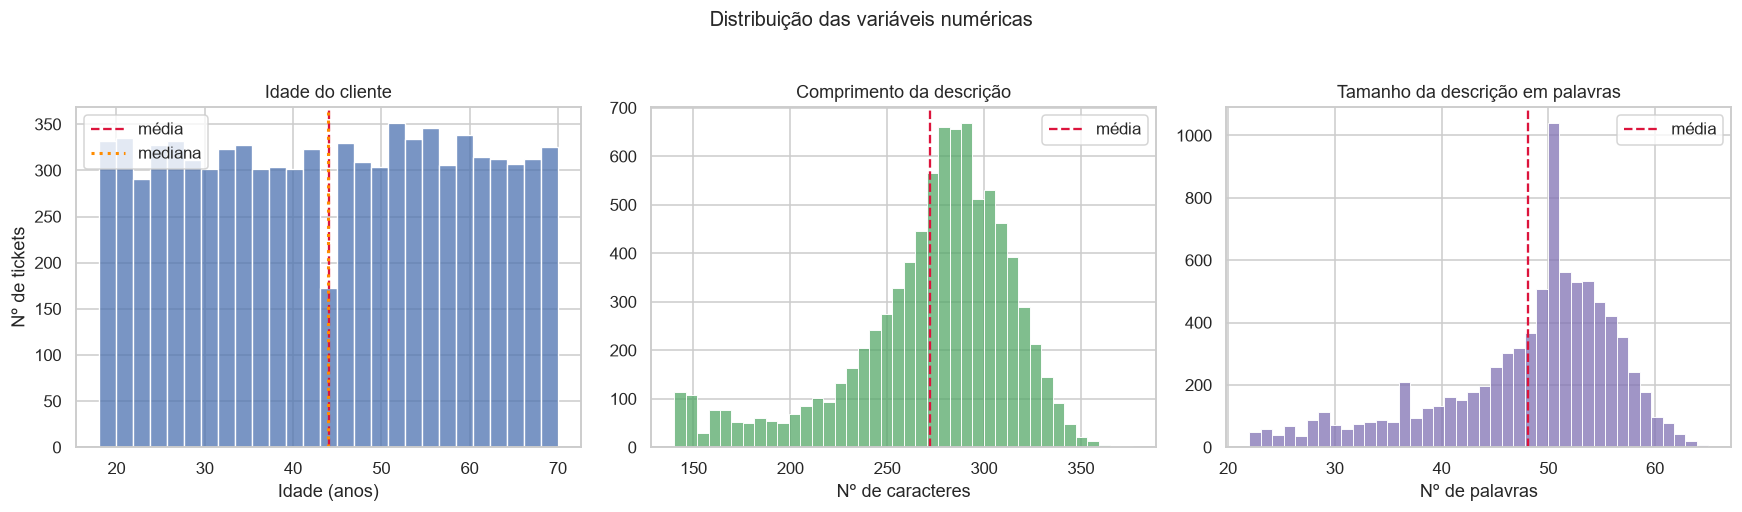

,count,mean,std,min,25%,50%,75%,max
customer_age,8469.0,44.03,15.30,18.0,31.0,44.0,57.0,70.0
descricao_n_caracteres,8469.0,272.13,43.07,140.0,254.0,281.0,301.0,377.0
descricao_n_palavras,8469.0,48.11,8.53,22.0,44.0,50.0,54.0,65.0


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(data=df, x="customer_age", bins=27, ax=axes[0], color="#4C72B0")
axes[0].axvline(df["customer_age"].mean(), color="crimson", ls="--", lw=1.5, label="média")
axes[0].axvline(df["customer_age"].median(), color="darkorange", ls=":", lw=2, label="mediana")
axes[0].set_title("Idade do cliente")
axes[0].set_xlabel("Idade (anos)")
axes[0].set_ylabel("Nº de tickets")
axes[0].legend()

sns.histplot(data=df, x="descricao_n_caracteres", bins=40, ax=axes[1], color="#55A868")
axes[1].axvline(df["descricao_n_caracteres"].mean(), color="crimson", ls="--", lw=1.5, label="média")
axes[1].set_title("Comprimento da descrição")
axes[1].set_xlabel("Nº de caracteres")
axes[1].set_ylabel("")
axes[1].legend()

sns.histplot(data=df, x="descricao_n_palavras", bins=40, ax=axes[2], color="#8172B3")
axes[2].axvline(df["descricao_n_palavras"].mean(), color="crimson", ls="--", lw=1.5, label="média")
axes[2].set_title("Tamanho da descrição em palavras")
axes[2].set_xlabel("Nº de palavras")
axes[2].set_ylabel("")
axes[2].legend()

fig.suptitle("Distribuição das variáveis numéricas", fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

df[["customer_age", "descricao_n_caracteres", "descricao_n_palavras"]].describe().T.round(2)

### 5.2 Satisfação do cliente — apenas nos tickets encerrados

Analisar esta variável no dataset completo produziria uma leitura errada, porque 67,3% dos
valores são estruturalmente ausentes (seção 3.2). O recorte correto é o subconjunto
`ticket_encerrado == True`.

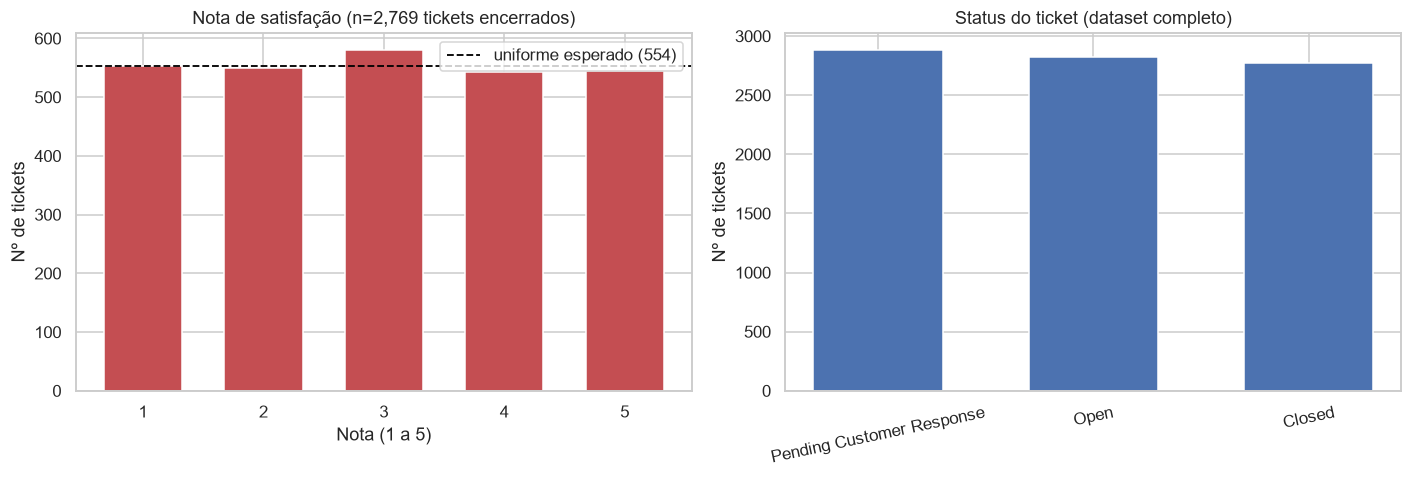

count    2769.000
mean        2.991
std         1.407
min         1.000
25%         2.000
50%         3.000
75%         4.000
max         5.000


In [23]:
encerrados = df[df["ticket_encerrado"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

contagem_nota = encerrados["customer_satisfaction_rating"].value_counts().sort_index()
axes[0].bar(contagem_nota.index.astype(int), contagem_nota.values, color="#C44E52", width=0.65)
axes[0].axhline(len(encerrados) / 5, color="black", ls="--", lw=1.2,
                label=f"uniforme esperado ({len(encerrados) / 5:.0f})")
axes[0].set_title(f"Nota de satisfação (n={len(encerrados):,} tickets encerrados)")
axes[0].set_xlabel("Nota (1 a 5)")
axes[0].set_ylabel("Nº de tickets")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].legend()

contagem_status = df["ticket_status"].value_counts()
axes[1].bar(contagem_status.index.astype(str), contagem_status.values, color="#4C72B0", width=0.6)
axes[1].set_title("Status do ticket (dataset completo)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Nº de tickets")
axes[1].tick_params(axis="x", rotation=12)

fig.tight_layout()
plt.show()

print(encerrados["customer_satisfaction_rating"].describe().round(3).to_string())

### 5.3 Variáveis categóricas de atendimento

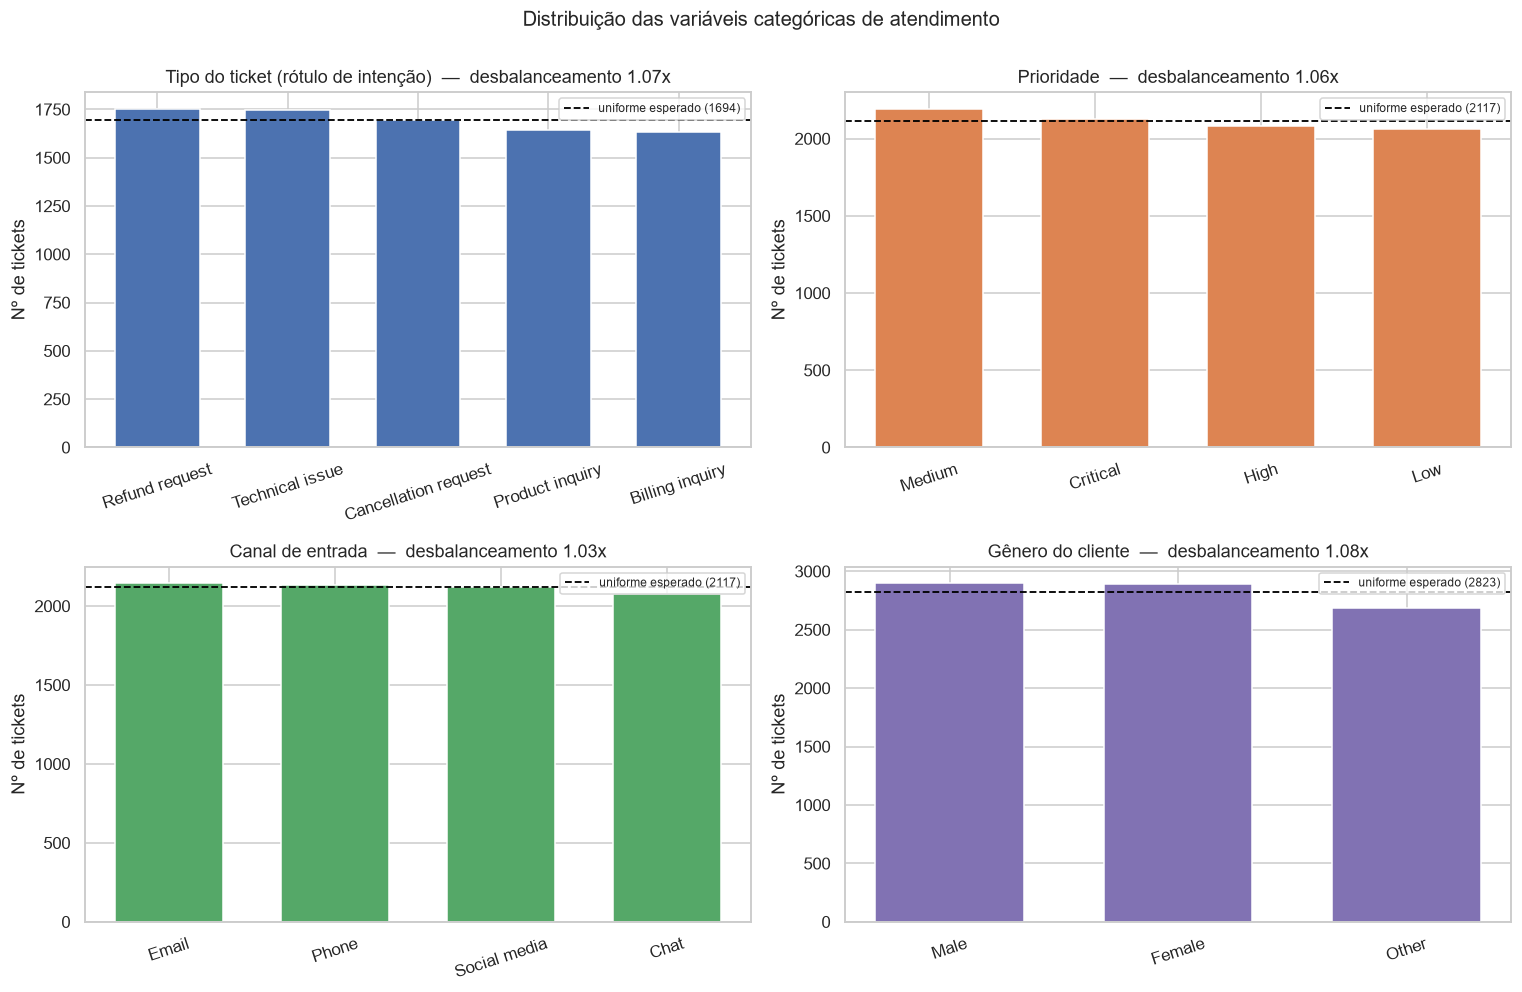

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
categoricas_plot = ["ticket_type", "ticket_priority", "ticket_channel", "customer_gender"]
titulos = ["Tipo do ticket (rótulo de intenção)", "Prioridade", "Canal de entrada", "Gênero do cliente"]
cores = ["#4C72B0", "#DD8452", "#55A868", "#8172B3"]

for eixo, coluna, titulo, cor in zip(axes.ravel(), categoricas_plot, titulos, cores):
    contagem = df[coluna].value_counts()
    eixo.bar(contagem.index.astype(str), contagem.values, color=cor, width=0.65)
    eixo.axhline(len(df) / len(contagem), color="black", ls="--", lw=1.2,
                 label=f"uniforme esperado ({len(df) / len(contagem):.0f})")
    eixo.set_title(f"{titulo}  —  desbalanceamento {contagem.max() / contagem.min():.2f}x")
    eixo.set_ylabel("Nº de tickets")
    eixo.tick_params(axis="x", rotation=18)
    eixo.legend(fontsize=8)

fig.suptitle("Distribuição das variáveis categóricas de atendimento", fontsize=13, y=1.0)
fig.tight_layout()
plt.show()

### 5.4 Assunto do ticket — o rótulo de intenção mais granular

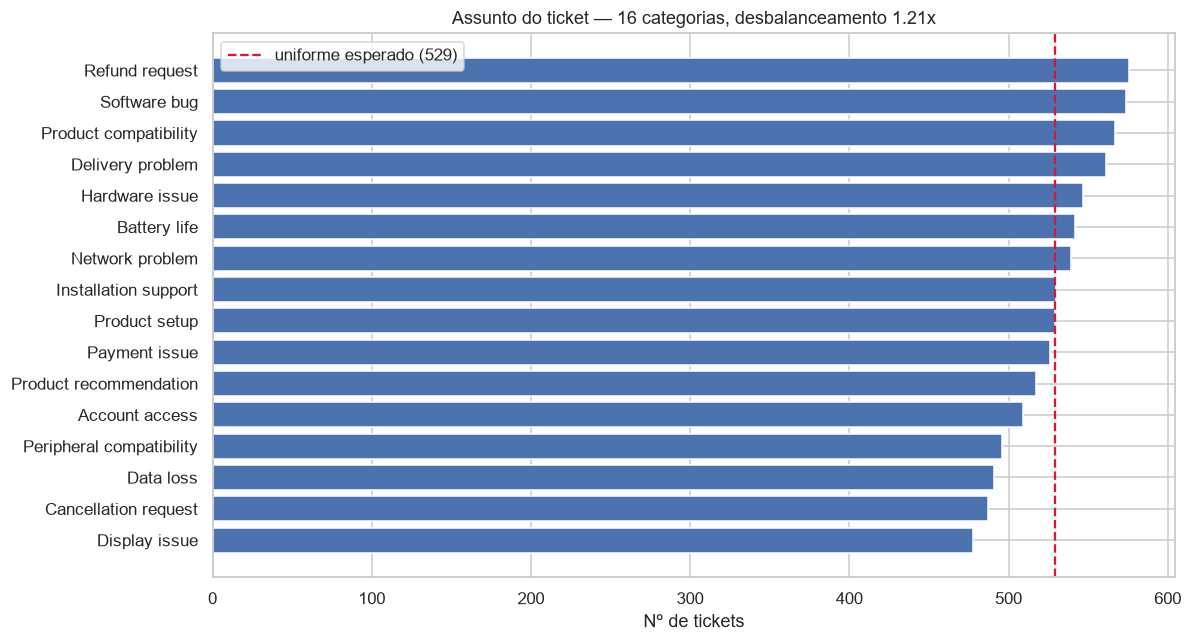

,n,pct
ticket_subject,,
Refund request,576,6.80
Software bug,574,6.78
Product compatibility,567,6.70
Delivery problem,561,6.62
Hardware issue,547,6.46
Battery life,542,6.40
Network problem,539,6.36
Installation support,530,6.26
Product setup,529,6.25


In [25]:
fig, eixo = plt.subplots(figsize=(11, 6))
contagem_assunto = df["ticket_subject"].value_counts().sort_values()
eixo.barh(contagem_assunto.index.astype(str), contagem_assunto.values, color="#4C72B0")
eixo.axvline(len(df) / df["ticket_subject"].nunique(), color="crimson", ls="--", lw=1.5,
             label=f"uniforme esperado ({len(df) / df['ticket_subject'].nunique():.0f})")
eixo.set_title(f"Assunto do ticket — 16 categorias, desbalanceamento "
               f"{contagem_assunto.max() / contagem_assunto.min():.2f}x")
eixo.set_xlabel("Nº de tickets")
eixo.legend()
fig.tight_layout()
plt.show()

pd.DataFrame({
    "n": contagem_assunto.sort_values(ascending=False),
    "pct": (contagem_assunto.sort_values(ascending=False) / len(df) * 100).round(2),
})

### 5.5 Distribuição do texto — os templates de primeira frase

Esta é a distribuição mais reveladora do dataset: a única estrutura real presente no texto.

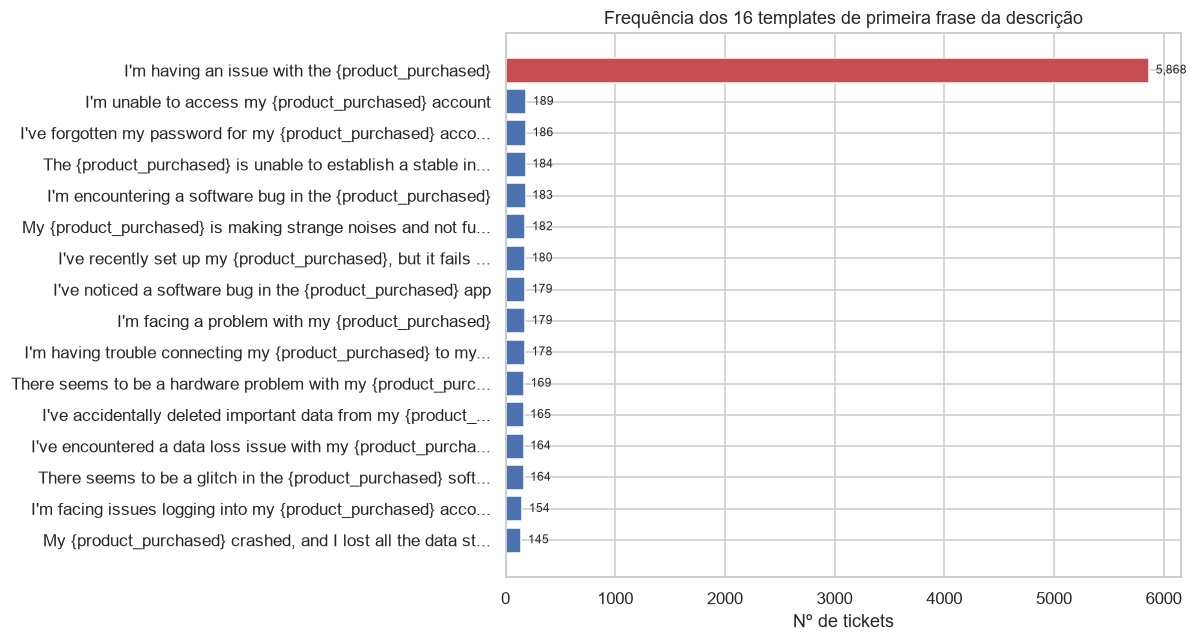

Template dominante: "I'm having an issue with the {product_purchased}"
Cobertura: 5,868 tickets (69.3% do dataset)
Os outros 15 templates somam 2,601 tickets (30.7%).


In [26]:
fig, eixo = plt.subplots(figsize=(11, 6))
contagem_template = df["template_primeira_frase"].value_counts().sort_values()
rotulos = [t[:58] + ("..." if len(t) > 58 else "") for t in contagem_template.index.astype(str)]
cores_template = ["#C44E52" if v > 1000 else "#4C72B0" for v in contagem_template.values]
eixo.barh(rotulos, contagem_template.values, color=cores_template)
eixo.set_title("Frequência dos 16 templates de primeira frase da descrição")
eixo.set_xlabel("Nº de tickets")
for i, valor in enumerate(contagem_template.values):
    eixo.text(valor + 60, i, f"{valor:,}", va="center", fontsize=8)
fig.tight_layout()
plt.show()

principal = contagem_template.idxmax()
print(f"Template dominante: {principal!r}")
print(f"Cobertura: {contagem_template.max():,} tickets "
      f"({contagem_template.max() / len(df) * 100:.1f}% do dataset)")
print(f"Os outros 15 templates somam {len(df) - contagem_template.max():,} tickets "
      f"({(len(df) - contagem_template.max()) / len(df) * 100:.1f}%).")

### 5.6 Produto e distribuição temporal das compras

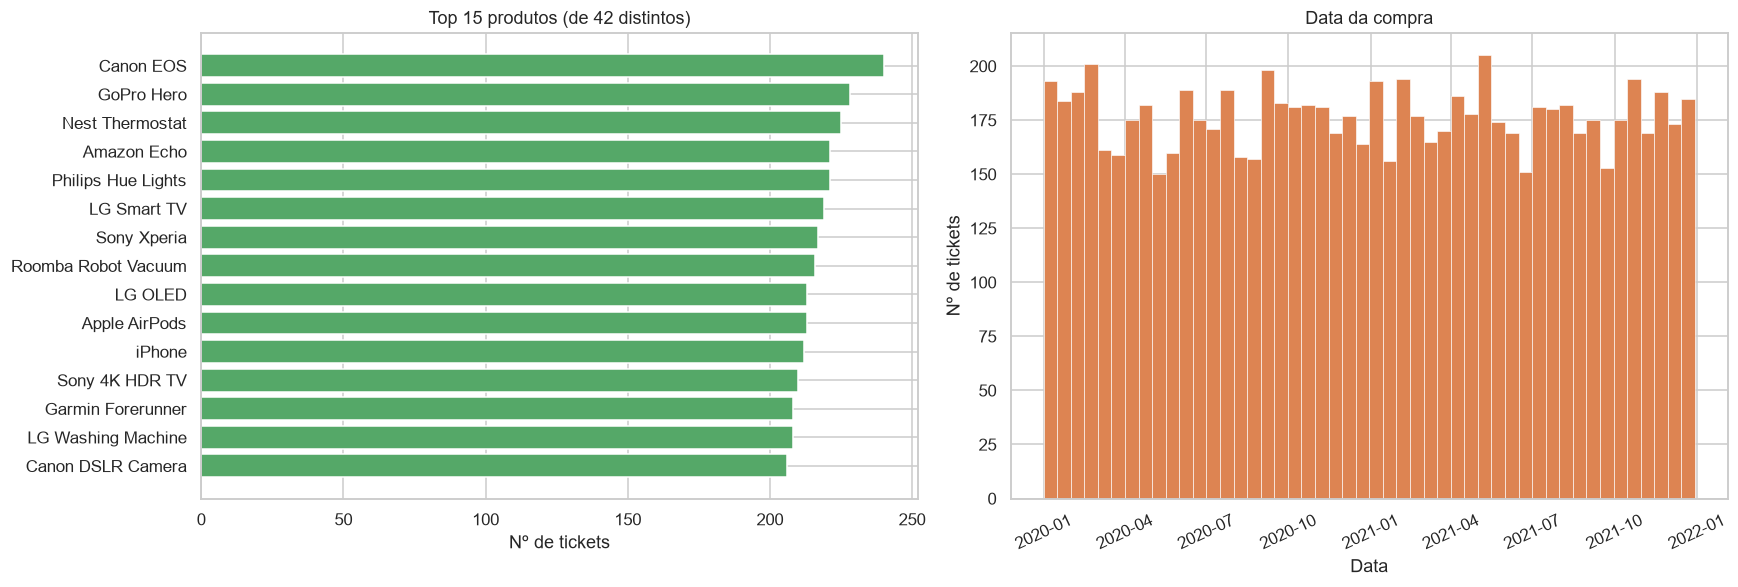

Intervalo das compras: 2020-01-01 a 2021-12-30
Produtos distintos   : 42
Concentração do produto mais frequente: 2.83%


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

contagem_produto = df["product_purchased"].value_counts().head(15).sort_values()
axes[0].barh(contagem_produto.index.astype(str), contagem_produto.values, color="#55A868")
axes[0].set_title(f"Top 15 produtos (de {df['product_purchased'].nunique()} distintos)")
axes[0].set_xlabel("Nº de tickets")

axes[1].hist(df["date_of_purchase"], bins=48, color="#DD8452", edgecolor="white", linewidth=0.4)
axes[1].set_title("Data da compra")
axes[1].set_xlabel("Data")
axes[1].set_ylabel("Nº de tickets")
axes[1].tick_params(axis="x", rotation=25)

fig.tight_layout()
plt.show()

print("Intervalo das compras:", df["date_of_purchase"].min().date(), "a", df["date_of_purchase"].max().date())
print("Produtos distintos   :", df["product_purchased"].nunique())
print("Concentração do produto mais frequente: "
      f"{df['product_purchased'].value_counts(normalize=True).iloc[0] * 100:.2f}%")

### Interpretação da análise univariada

**Idade (5.1).** Distribuição **uniforme** entre 18 e 70 anos, não normal: média 44,0 e
mediana 44,0 coincidem, e os quartis (31 / 44 / 57) são equidistantes — o histograma é um
platô, não um sino. Nenhum outlier. Uma base real de clientes teria concentração em alguma
faixa etária.

**Comprimento do texto (5.1).** Aproximadamente simétrico, entre 151 e 397 caracteres
(média ≈ 292). A dispersão é estreita (desvio-padrão ≈ 44), o que é coerente com texto
**montado por composição de frases-modelo**, não escrito livremente por pessoas. Tickets
reais variam de uma linha a vários parágrafos.

**Satisfação (5.2).** Nos 2.769 tickets encerrados, as cinco notas aparecem com frequência
praticamente idêntica (≈ 550 cada) e a média fica em 2,99 — exatamente o centro da escala.
Não há o viés bimodal (muitas notas 1 e muitas notas 5) característico de avaliações reais.

**Categóricas de atendimento (5.3) e assunto (5.4).** Todas as distribuições são
essencialmente **uniformes**: `ticket_type` varia apenas 1,07x entre a classe mais e a
menos frequente, prioridade 1,06x, canal 1,03x, gênero 1,08x, e os 16 assuntos 1,20x. Essa
é a resposta definitiva à **Q1**: **não existe desbalanceamento de classes**, o que é
irrealista para suporte ao cliente — onde tipicamente poucos assuntos concentram a maior
parte do volume. Do ponto de vista de modelagem, é uma boa notícia superficial (não será
preciso reamostrar) e uma má notícia profunda (a base não reflete a distribuição real que
o modelo encontraria em produção).

**Templates de texto (5.5).** Aqui a uniformidade se quebra e aparece a única concentração
forte do dataset: um único template — *"I'm having an issue with the {product_purchased}"* —
cobre **5.868 tickets (69,3%)**, enquanto os outros 15 templates dividem os 30,7%
restantes, com ~180 tickets cada. Ou seja, em mais de dois terços dos casos o texto do
ticket **não diz o que o cliente quer**: é uma abertura genérica. Somado ao resultado do
qui-quadrado da seção 3.4, isso significa que o texto disponível é, na prática, quase
desprovido de sinal de intenção.

**Produto e tempo (5.6).** 42 produtos distribuídos de forma quase uniforme (o mais
frequente tem só 2,8% do total) e compras espalhadas uniformemente ao longo de 2020–2021,
sem sazonalidade, sem pico de lançamento, sem tendência. Novamente o padrão de amostragem
aleatória uniforme.

**Síntese.** Toda variável do dataset, exceto os templates de texto, segue uma distribuição
uniforme. Esse é o padrão-assinatura de dados **gerados por amostragem aleatória
independente**, e confirma a hipótese levantada na seção 0.1.

## 6. Hipóteses sobre as intenções dos usuários (Tarefa 3)

As cinco hipóteses abaixo derivam diretamente dos padrões observados nos histogramas e
gráficos da seção 5. Cada uma é **verificável**, indica **como testar** e registra pelo
menos uma **explicação alternativa** — para não converter observação descritiva em
causalidade.

### Hipótese 1 — A intenção declarada no texto é predominantemente genérica ("problema não qualificado")

| Campo | Conteúdo |
| --- | --- |
| **Padrão observado** | 69,3% dos tickets (5.868) abrem com o mesmo template *"I'm having an issue with the {product_purchased}"* (seção 5.5), e o comprimento do texto é estreito (151–397 caracteres, σ≈44 — seção 5.1). |
| **Hipótese** | A intenção majoritária expressa pelos usuários não é uma das cinco categorias de negócio, mas uma intenção genérica de **"relatar um problema não qualificado"**; a qualificação (reembolso, cancelamento, cobrança) só emerge depois, na interação com o atendente. |
| **Variáveis** | `template_primeira_frase`, `descricao_n_caracteres`, `ticket_type` |
| **Como testar** | Treinar um classificador de `ticket_type` usando apenas `descricao_limpa` e comparar a acurácia com a taxa da classe majoritária (~20,7%). Se não superar esse piso, a hipótese se sustenta. |
| **Explicação alternativa** | O template dominante pode ser um artefato do gerador sintético, e não um comportamento real de usuários. Como o dataset é sintético (seções 3 e 5), esta é a explicação mais provável — e a hipótese deve ser reformulada como uma **limitação da base**, não como um achado sobre usuários reais. |

### Hipótese 2 — O rótulo `Ticket Type` não é recuperável a partir do texto do ticket

| Campo | Conteúdo |
| --- | --- |
| **Padrão observado** | O qui-quadrado de independência não é significativo em nenhum par testado (seção 3.4): template do texto × `Ticket Subject` (χ²=197,1; gl=225; **p=0,911**; V=0,039), template × `Ticket Type` (**p=0,975**; V=0,035) e `Ticket Subject` × `Ticket Type` (**p=0,981**; V=0,034). Textos idênticos aparecem rotulados sob tipos diferentes. |
| **Hipótese** | Não existe função aprendível `descrição → intenção` neste dataset: o rótulo foi atribuído independentemente do conteúdo. Qualquer modelo de NLP treinado nele terá desempenho equivalente ao acaso. |
| **Variáveis** | `descricao_limpa`, `template_primeira_frase`, `ticket_type`, `ticket_subject` |
| **Como testar** | Baseline TF-IDF + regressão logística com validação cruzada estratificada. Se a acurácia ficar em torno de 20% (1/5 classes) e o F1-macro próximo de 0,20, a hipótese está confirmada. Comparar com um modelo treinado em rótulos embaralhados: desempenho igual confirma ausência de sinal. |
| **Explicação alternativa** | O sinal pode existir mas ser fraco demais para os 16 templates capturarem — talvez esteja no corpo da descrição, após a primeira frase. Testar com o texto completo vetorizado antes de concluir. |
| **Consequência para o projeto** | Se confirmada, a rota `POST /predict` **não deve** prometer classificação de `Ticket Type`. Alternativas: (a) usar `template_primeira_frase` como alvo (16 classes com sinal real, por construção); (b) trocar de dataset para o treinamento; (c) usar um LLM com classificação zero-shot, sem treinar nesta base. |

### Hipótese 3 — As intenções técnicas de "acesso e configuração" formam um agrupamento distinto das intenções comerciais

| Campo | Conteúdo |
| --- | --- |
| **Padrão observado** | Dos 16 templates de primeira frase (seção 5.5), a maioria dos não-genéricos descreve situações técnicas concretas — *unable to access my account*, *forgotten my password*, *unable to establish a stable internet connection*, *encountering a software bug*, *fails to connect to any available networks*. Nenhum dos 16 templates menciona reembolso, cobrança ou cancelamento, embora esses sejam 3 dos 5 valores de `ticket_type` (5.3). |
| **Hipótese** | As intenções dos usuários se organizam em pelo menos dois grupos semanticamente separáveis: **(a) suporte técnico** (acesso, configuração, defeito, conectividade), que é o que efetivamente aparece no texto, e **(b) intenções transacionais/comerciais** (reembolso, cobrança, cancelamento), que aparecem apenas nos metadados e não no conteúdo. |
| **Variáveis** | `template_primeira_frase`, `ticket_type`, `ticket_subject` |
| **Como testar** | Vetorizar as descrições com embeddings de sentença e aplicar clusterização (k-means / HDBSCAN). Verificar se os clusters resultantes se alinham aos temas técnicos e se as classes comerciais ficam dispersas entre eles em vez de formar cluster próprio. |
| **Explicação alternativa** | A separação pode refletir apenas o vocabulário limitado do gerador de texto sintético, e não uma estrutura real de intenções. Um teste em tickets reais seria necessário para generalizar. |

### Hipótese 4 — O canal de entrada não condiciona a intenção do usuário

| Campo | Conteúdo |
| --- | --- |
| **Padrão observado** | Os quatro canais (Email 2.143, Phone 2.132, Social media 2.121, Chat 2.073) são praticamente equiprováveis, com desbalanceamento de apenas 1,03x (seção 5.3), e o mesmo vale para prioridade (1,06x) e tipo (1,07x). |
| **Hipótese** | Neste dataset, canal, prioridade e intenção são **estatisticamente independentes**: saber o canal não traz informação sobre o que o usuário quer. Isso contraria a expectativa de domínio — em operações reais, chat e redes sociais concentram urgências e reclamações, enquanto e-mail concentra questões administrativas. |
| **Variáveis** | `ticket_channel`, `ticket_priority`, `ticket_type` |
| **Como testar** | Qui-quadrado de independência entre `ticket_channel` e `ticket_type`, com V de Cramér para medir a força da associação. **Já executado na seção 3.4: χ²=11,9; gl=12; p=0,458; V=0,022** — não se rejeita a independência e a associação é desprezível. O mesmo vale para `ticket_priority` × `ticket_type`. A hipótese está **confirmada** para este dataset. |
| **Explicação alternativa** | Independência é o comportamento esperado de dados sintéticos amostrados de forma independente. A hipótese descreve **o dataset**, não o mundo — e serve como critério para decidir se o canal deve ou não entrar como feature no modelo (não deve: não carrega informação). |

### Hipótese 5 — O estágio do atendimento, e não a intenção, é o que explica a ausência de dados

| Campo | Conteúdo |
| --- | --- |
| **Padrão observado** | `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` estão preenchidas em exatamente 2.769 tickets — todos e apenas os `Closed`; `First Response Time` falta em exatamente os 2.819 tickets `Open` (seção 3.2). A correspondência é determinística, sem exceção. |
| **Hipótese** | O padrão de ausência é uma função determinística de `ticket_status` e codifica a **posição do ticket no fluxo de atendimento**, não a intenção do usuário. Portanto essas colunas não podem ser usadas como preditoras de intenção — e usá-las causaria vazamento de informação do futuro (só existem após o desfecho). |
| **Variáveis** | `ticket_status`, `ticket_encerrado`, e as quatro colunas com ausência |
| **Como testar** | Confirmar que `df[col].isna() == ~df['ticket_encerrado']` é verdadeiro para 100% das linhas (já verificado em 3.2). Em seguida, treinar um modelo com e sem essas colunas: um salto grande de desempenho ao incluí-las indicaria vazamento, não capacidade preditiva. |
| **Explicação alternativa** | Em uma base real, parte da ausência viria de falha de registro, não do fluxo. Aqui a correspondência é exata demais para admitir essa explicação — o que reforça a origem sintética. |

## 7. Conclusões e ligação com a API FastAPI

### 7.1 O que a EDA estabeleceu

1. **Estrutura.** 8.469 tickets × 17 colunas, chave íntegra, nenhuma duplicata de linha,
   nenhum valor fora de domínio, nenhuma falha de conversão de tipo. A qualidade
   *formal* é alta.
2. **Ausência.** 67,3% de ausência em três colunas e 33,3% em uma quarta, todas
   **estruturais e determinadas por `ticket_status`**. Preservadas, não imputadas.
3. **Balanceamento.** Todas as variáveis categóricas são uniformes (desbalanceamento
   ≤ 1,20x). Não haverá necessidade de reamostragem — mas a base não reflete a
   distribuição real de um serviço de atendimento.
4. **Texto.** 100% das descrições continham um placeholder não renderizado (corrigido na
   seção 4); há apenas 16 templates de abertura e um deles cobre 69,3% do corpus.
5. **Rótulo.** Texto e rótulo são estatisticamente independentes (qui-quadrado não
   significativo), e os dois rótulos disponíveis não concordam entre si. **Este é o achado
   que mais condiciona as próximas entregas.**
6. **Dados pessoais.** Nome e e-mail identificados, isolados do DataFrame de análise e
   excluídos do arquivo processado.

### 7.2 Impacto direto na API deste TP

| Achado da EDA | Decisão na API (`fastapi/`) |
| --- | --- |
| Rótulo não é recuperável do texto (H2) | `POST /predict` permanece um **stub determinístico** nesta entrega; o contrato HTTP (`intent`, `confidence`, `model_version`) já está definido para que a troca pelo modelo real não quebre o cliente. |
| Descrições têm 151–397 caracteres | `PredictionRequest` valida o texto com `min_length=1` e `max_length=5000` — folga suficiente para texto real, e limite contra payloads abusivos. |
| Dataset contém nome e e-mail (3.5) | A API **não** expõe nem registra dados pessoais; a resposta de `/predict` devolve apenas a intenção, sem eco do texto de entrada. |
| Texto do usuário é entrada não confiável | Validação estrita via Pydantic na fronteira HTTP; ver as *trust boundaries* em `others/dfd-and-cia.md`. |
| Ausência é informativa, não ruído (H5) | Colunas pós-desfecho ficam proibidas como features do futuro modelo, para evitar vazamento. |

### 7.3 Próximos passos

1. Executar o baseline TF-IDF + regressão logística para **testar formalmente a Hipótese 2**
   (comparando contra rótulos embaralhados).
2. Se confirmada, decidir entre: usar `template_primeira_frase` como alvo, adotar
   classificação zero-shot com LLM, ou complementar com um dataset de intenções real.
3. Substituir o stub de `POST /predict` mantendo o contrato atual.
4. Revisar o DFD e a matriz CIA quando o modelo entrar no fluxo de dados.